## Ashutosh Mehta
## Assignment 5

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Question 1: Histogram Equalization

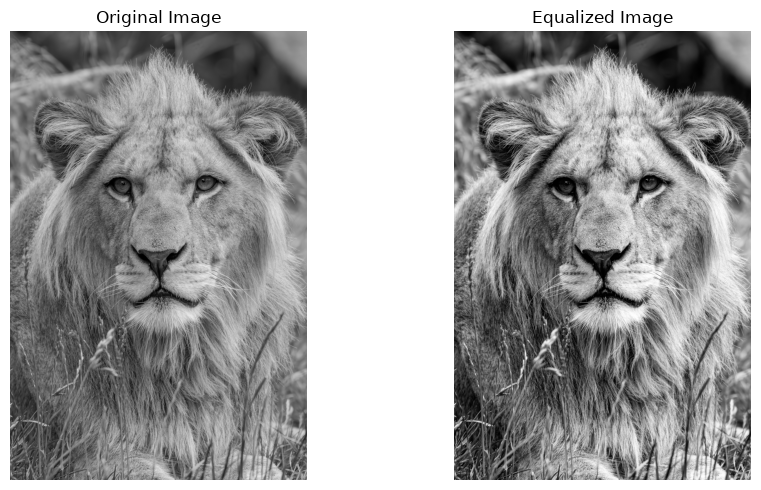

In [2]:
img = cv2.imread('lion.jpg', cv2.IMREAD_GRAYSCALE)

# 2. Perform histogram equalization
equalized_img = cv2.equalizeHist(img)

# 3. Display original and equalized images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(equalized_img, cmap='gray')
plt.title('Equalized Image')
plt.axis('off')

plt.tight_layout()
plt.show()

### QUESTION 2: Histogram Matching
### (Using equalized_img directly as the reference)

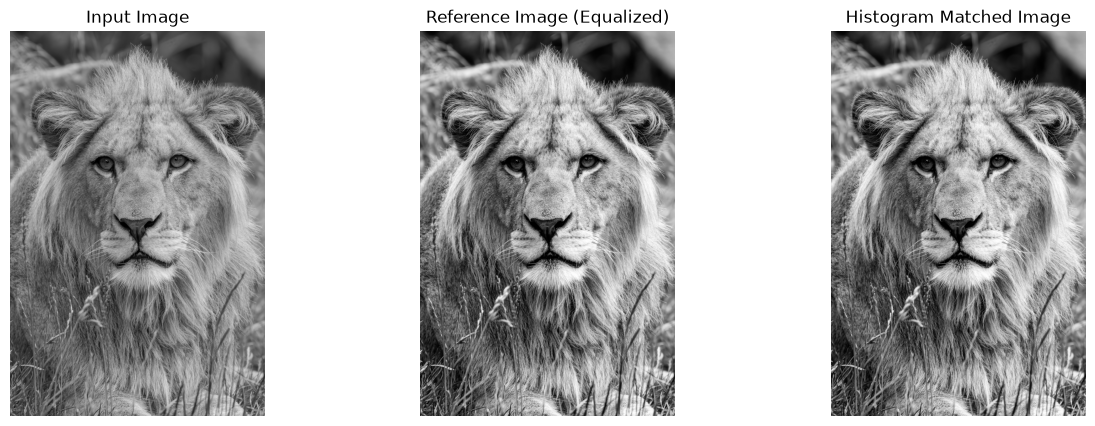

In [3]:
src = img
ref = equalized_img  # Set equalized image as reference

# Calculate normalized Cumulative Distribution Functions (CDFs)
src_hist, _ = np.histogram(src.flatten(), 256, [0, 256])
ref_hist, _ = np.histogram(ref.flatten(), 256, [0, 256])

src_cdf_normalized = src_hist.cumsum() / src_hist.sum()
ref_cdf_normalized = ref_hist.cumsum() / ref_hist.sum()

# Create lookup table for matching
lookup_table = np.zeros(256, dtype=np.uint8)
for i in range(256):
    diff = np.abs(ref_cdf_normalized - src_cdf_normalized[i])
    lookup_table[i] = diff.argmin()

# Map input image to reference histogram
matched_img = cv2.LUT(src, lookup_table)

# Display Question 2 Results
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(src, cmap='gray')
plt.title('Input Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(ref, cmap='gray')
plt.title('Reference Image (Equalized)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(matched_img, cmap='gray')
plt.title('Histogram Matched Image')
plt.axis('off')
plt.show()